# ATDL Assignment 1 — Task 4 (baseline half): FP32 ResNet18, no KD

**Why this notebook exists:** the assignment requires a three-way comparison table — teacher (ResNet34, FP32) vs. FP32 ResNet18 baseline (no KD, no quantization) vs. ternary ResNet18 (KD+QAT). This notebook produces the middle column. Its checkpoint will *also* be used to warm-start the ternary student's latent weights in Task 3 (rather than random init), which tends to give QAT a much more stable starting point than training a ternary network from scratch.

**Identical to the Task 1 notebook in every way that matters for a fair comparison:**
- Same `SEED = 42` → identical 45k/5k/10k data split.
- Same augmentation, same "bag of tricks" (Cutout, label smoothing, no weight decay on BN/bias, zero-init residual, EMA).
- Same warmup + `ReduceLROnPlateau` + early-stopping schedule.

**Only difference:** `[2, 2, 2, 2]` BasicBlocks (ResNet18) instead of `[3, 4, 6, 3]` (ResNet34), and **no distillation** — this is trained purely against the true labels, so it's the fair "what if we just used a smaller FP32 network" baseline.

**Before running:** Runtime > Change runtime type > T4 GPU.

In [ ]:
import os, sys

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    DRIVE_DIR = "/content/drive/MyDrive/atdl"
    os.makedirs(DRIVE_DIR, exist_ok=True)
    print(f"Google Drive mounted. Saving checkpoints/plots to: {DRIVE_DIR}")
else:
    DRIVE_DIR = "."
    print("Not running in Colab -- saving to the local working directory.")

CKPT_PATH = os.path.join(DRIVE_DIR, "resnet18_cifar10_fp32_baseline_best.pth")
CURVE_PATH = os.path.join(DRIVE_DIR, "resnet18_baseline_training_curves.png")
TEACHER_CKPT = os.path.join(DRIVE_DIR, "resnet34_cifar10_teacher_best.pth")

if not os.path.exists(TEACHER_CKPT):
    print(f"NOTE: teacher checkpoint not found yet at {TEACHER_CKPT} -- that's fine, "
          "this notebook doesn't need it. Just confirming Task 1 ran, since Task 3 will need it next.")
else:
    print(f"Found teacher checkpoint at {TEACHER_CKPT} -- Task 1 is done.")

Mounted at /content/drive
Google Drive mounted. Saving checkpoints/plots to: /content/drive/MyDrive/atdl
Found teacher checkpoint at /content/drive/MyDrive/atdl/resnet34_cifar10_teacher_best.pth -- Task 1 is done.


## Reproducibility

Same `SEED` as the Task 1 notebook. This is what guarantees this baseline sees the *exact same* 45k/5k/10k partition as the teacher and (later) the student — without this, the three-way comparison table wouldn't be apples-to-apples.

In [ ]:
import copy
import time
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Subset
from torch.amp import autocast, GradScaler
import matplotlib.pyplot as plt

SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed()
torch.backends.cudnn.benchmark = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
if DEVICE.type != "cuda":
    print("WARNING: no GPU detected. Go to Runtime > Change runtime type > T4 GPU.")

Using device: cuda


## Model: CIFAR-adapted ResNet18

Identical `BasicBlock`/stem to the Task 1 teacher -- only the per-stage block counts differ (`[2,2,2,2]` vs `[3,4,6,3]`), which is the textbook ResNet18-vs-ResNet34 distinction from He et al. Keeping the block and stem code byte-for-byte identical to Task 1 (not just architecturally equivalent) matters here, since the ternary version of this exact class is what Task 2/3 will build on top of.

In [ ]:
class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_planes, planes, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=3, stride=stride,
                                padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=1,
                                padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != self.expansion * planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, self.expansion * planes, kernel_size=1,
                          stride=stride, bias=False),
                nn.BatchNorm2d(self.expansion * planes),
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = out + self.shortcut(x)
        return F.relu(out)


class ResNetCIFAR(nn.Module):
    def __init__(self, block, num_blocks, num_classes=10):
        super().__init__()
        self.in_planes = 64
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.layer1 = self._make_layer(block, 64, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 128, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 256, num_blocks[2], stride=2)
        self.layer4 = self._make_layer(block, 512, num_blocks[3], stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * block.expansion, num_classes)

    def _make_layer(self, block, planes, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for s in strides:
            layers.append(block(self.in_planes, planes, s))
            self.in_planes = planes * block.expansion
        return nn.Sequential(*layers)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = self.avgpool(out)
        out = torch.flatten(out, 1)
        return self.fc(out)


def ResNet18(num_classes=10):
    return ResNetCIFAR(BasicBlock, [2, 2, 2, 2], num_classes)


def zero_init_residual(model):
    for m in model.modules():
        if isinstance(m, BasicBlock):
            nn.init.zeros_(m.bn2.weight)

## Data pipeline

Byte-for-byte identical to the Task 1 notebook — same transforms, same `SEED`-based 45k/5k/10k split, same `clean_train_loader` for an honest (non-augmented) train accuracy at the end.

In [ ]:
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD = (0.2470, 0.2435, 0.2616)


class Cutout:
    def __init__(self, n_holes=1, length=16):
        self.n_holes = n_holes
        self.length = length

    def __call__(self, img):
        h, w = img.size(1), img.size(2)
        mask = torch.ones((h, w), dtype=img.dtype)
        for _ in range(self.n_holes):
            y = random.randint(0, h - 1)
            x = random.randint(0, w - 1)
            y1, y2 = max(y - self.length // 2, 0), min(y + self.length // 2, h)
            x1, x2 = max(x - self.length // 2, 0), min(x + self.length // 2, w)
            mask[y1:y2, x1:x2] = 0.0
        return img * mask.unsqueeze(0)


train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
    Cutout(n_holes=1, length=16),
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])


def get_dataloaders(data_dir="./data", batch_size=128, num_workers=2, n_val=5000):
    full_train_aug = torchvision.datasets.CIFAR10(
        root=data_dir, train=True, download=True, transform=train_transform)
    full_train_plain = torchvision.datasets.CIFAR10(
        root=data_dir, train=True, download=True, transform=eval_transform)
    test_set = torchvision.datasets.CIFAR10(
        root=data_dir, train=False, download=True, transform=eval_transform)

    n_total = len(full_train_aug)
    n_train = n_total - n_val

    g = torch.Generator().manual_seed(SEED)
    perm = torch.randperm(n_total, generator=g).tolist()
    train_idx, val_idx = perm[:n_train], perm[n_train:]

    train_set = Subset(full_train_aug, train_idx)
    val_set = Subset(full_train_plain, val_idx)
    clean_train_set = Subset(full_train_plain, train_idx)

    train_loader = torch.utils.data.DataLoader(
        train_set, batch_size=batch_size, shuffle=True,
        num_workers=num_workers, pin_memory=True, drop_last=True)
    val_loader = torch.utils.data.DataLoader(
        val_set, batch_size=256, shuffle=False,
        num_workers=num_workers, pin_memory=True)
    test_loader = torch.utils.data.DataLoader(
        test_set, batch_size=256, shuffle=False,
        num_workers=num_workers, pin_memory=True)
    clean_train_loader = torch.utils.data.DataLoader(
        clean_train_set, batch_size=256, shuffle=False,
        num_workers=num_workers, pin_memory=True)

    return train_loader, val_loader, test_loader, clean_train_loader

## EMA and no-decay parameter groups

Same as Task 1 -- kept identical so any accuracy difference you observe later is attributable to model capacity (ResNet18 vs ResNet34) and architecture alone, not to a training-recipe mismatch.

In [ ]:
class ModelEMA:
    def __init__(self, model, decay=0.9998):
        self.decay = decay
        self.ema = copy.deepcopy(model).eval()
        for p in self.ema.parameters():
            p.requires_grad_(False)

    @torch.no_grad()
    def update(self, model):
        msd = model.state_dict()
        for k, v_ema in self.ema.state_dict().items():
            v = msd[k]
            if v.dtype.is_floating_point:
                v_ema.mul_(self.decay).add_(v.detach(), alpha=1 - self.decay)
            else:
                v_ema.copy_(v)


def get_param_groups(model, weight_decay):
    decay, no_decay = [], []
    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        if param.ndim <= 1 or name.endswith(".bias"):
            no_decay.append(param)
        else:
            decay.append(param)
    return [
        {"params": decay, "weight_decay": weight_decay},
        {"params": no_decay, "weight_decay": 0.0},
    ]

## Train / eval loops

Same non-deprecated `torch.amp` API as Task 1.

In [ ]:
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
            out = model(x)
            loss = criterion(out, y)
            total_loss += loss.item() * x.size(0)
            correct += (out.argmax(1) == y).sum().item()
            total += x.size(0)
    return total_loss / total, 100.0 * correct / total


def train_one_epoch(model, loader, criterion, optimizer, scaler, ema):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)

        with autocast(device_type=DEVICE.type, enabled=(DEVICE.type == "cuda")):
            out = model(x)
            loss = criterion(out, y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        ema.update(model)

        total_loss += loss.item() * x.size(0)
        correct += (out.argmax(1) == y).sum().item()
        total += x.size(0)
    return total_loss / total, 100.0 * correct / total

## Training config and main loop

Same warmup + `ReduceLROnPlateau` + early-stopping recipe as Task 1, same epoch ceiling (200) with early stopping deciding the real duration. The honest train/test gap (clean, non-augmented train accuracy vs. test accuracy) is computed the same way as the Task 1 fix.

In [ ]:
def main():
    EPOCHS = 200                # CEILING -- early stopping decides real duration
    WARMUP_EPOCHS = 5
    BATCH_SIZE = 128
    LR = 0.1
    MOMENTUM = 0.9
    WEIGHT_DECAY = 5e-4
    LABEL_SMOOTHING = 0.1
    EMA_DECAY = 0.9998
    LR_PATIENCE = 8
    LR_FACTOR = 0.5
    MIN_LR = 1e-4
    EARLY_STOP_PATIENCE = 20
    MIN_DELTA = 0.05

    train_loader, val_loader, test_loader, clean_train_loader = get_dataloaders(batch_size=BATCH_SIZE)

    model = ResNet18(num_classes=10).to(DEVICE)
    zero_init_residual(model)

    criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
    optimizer = optim.SGD(get_param_groups(model, WEIGHT_DECAY), lr=LR,
                           momentum=MOMENTUM, nesterov=True)

    warmup_sched = optim.lr_scheduler.LinearLR(optimizer, start_factor=0.01,
                                                total_iters=WARMUP_EPOCHS)
    plateau_sched = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=LR_FACTOR, patience=LR_PATIENCE, min_lr=MIN_LR)

    scaler = GradScaler(device=DEVICE.type, enabled=(DEVICE.type == "cuda"))
    ema = ModelEMA(model, decay=EMA_DECAY)

    history = {k: [] for k in [
        "train_loss", "train_acc",
        "val_acc_raw", "val_acc_ema",
        "test_acc_raw", "test_acc_ema", "lr",
    ]}
    best_val_acc, best_source = 0.0, None
    epochs_without_improvement = 0

    for epoch in range(1, EPOCHS + 1):
        t0 = time.time()
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, scaler, ema)

        val_acc_raw = evaluate(model, val_loader, criterion)[1]
        val_acc_ema = evaluate(ema.ema, val_loader, criterion)[1]
        test_acc_raw = evaluate(model, test_loader, criterion)[1]
        test_acc_ema = evaluate(ema.ema, test_loader, criterion)[1]

        if epoch <= WARMUP_EPOCHS:
            warmup_sched.step()
        else:
            plateau_sched.step(val_acc_ema)

        cur_lr = optimizer.param_groups[0]["lr"]
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_acc_raw"].append(val_acc_raw)
        history["val_acc_ema"].append(val_acc_ema)
        history["test_acc_raw"].append(test_acc_raw)
        history["test_acc_ema"].append(test_acc_ema)
        history["lr"].append(cur_lr)

        improved = False
        for source, v_acc, sd in [("raw", val_acc_raw, model.state_dict()),
                                   ("ema", val_acc_ema, ema.ema.state_dict())]:
            if v_acc > best_val_acc + MIN_DELTA:
                best_val_acc = v_acc
                best_source = source
                improved = True
                torch.save({
                    "epoch": epoch,
                    "model_state_dict": copy.deepcopy(sd),
                    "val_acc": v_acc,
                    "source": source,
                    "seed": SEED,
                    "arch": "resnet18_cifar_fp32_baseline",
                }, CKPT_PATH)

        epochs_without_improvement = 0 if improved else epochs_without_improvement + 1

        dt = time.time() - t0
        print(f"Epoch {epoch:3d}/{EPOCHS} | lr {cur_lr:.5f} | "
              f"train {train_loss:.4f}/{train_acc:.2f}% | "
              f"val raw/ema {val_acc_raw:.2f}%/{val_acc_ema:.2f}% | "
              f"test raw/ema {test_acc_raw:.2f}%/{test_acc_ema:.2f}% | "
              f"best_val {best_val_acc:.2f}% ({best_source}) | "
              f"no_improve {epochs_without_improvement}/{EARLY_STOP_PATIENCE} | {dt:.1f}s")

        if epochs_without_improvement >= EARLY_STOP_PATIENCE:
            print(f"\nEarly stopping at epoch {epoch}: no val-accuracy improvement "
                  f"(> {MIN_DELTA} pts) for {EARLY_STOP_PATIENCE} epochs. "
                  f"Best: {best_val_acc:.2f}% ({best_source}) at epoch "
                  f"{epoch - epochs_without_improvement}.")
            break

    best_ckpt = torch.load(CKPT_PATH, map_location=DEVICE)
    eval_model = ResNet18(num_classes=10).to(DEVICE)
    eval_model.load_state_dict(best_ckpt["model_state_dict"])

    _, final_test_acc = evaluate(eval_model, test_loader, criterion)
    _, honest_train_acc = evaluate(eval_model, clean_train_loader, criterion)

    print(f"\nBest checkpoint: epoch {best_ckpt['epoch']}, source={best_ckpt['source']}, "
          f"val_acc {best_ckpt['val_acc']:.2f}%")
    print(f"Final test accuracy: {final_test_acc:.2f}%")
    print(f"Honest clean train accuracy (same 45k images, no augmentation): {honest_train_acc:.2f}%")
    print(f"Honest train/test gap: {honest_train_acc - final_test_acc:.2f} points")
    print(f"Checkpoint saved to: {CKPT_PATH}")

    return history

In [ ]:
history = main()

100%|██████████| 170M/170M [00:32<00:00, 5.23MB/s]


Epoch   1/200 | lr 0.02080 | train 2.1639/22.25% | val raw/ema 27.42%/9.24% | test raw/ema 27.73%/9.90% | best_val 27.42% (raw) | no_improve 0/20 | 51.3s
Epoch   2/200 | lr 0.04060 | train 1.9165/32.51% | val raw/ema 42.06%/9.42% | test raw/ema 41.66%/9.93% | best_val 42.06% (raw) | no_improve 0/20 | 35.6s
Epoch   3/200 | lr 0.06040 | train 1.6763/45.29% | val raw/ema 51.00%/9.42% | test raw/ema 51.05%/10.00% | best_val 51.00% (raw) | no_improve 0/20 | 36.8s
Epoch   4/200 | lr 0.08020 | train 1.5066/54.25% | val raw/ema 59.06%/9.42% | test raw/ema 58.55%/10.00% | best_val 59.06% (raw) | no_improve 0/20 | 37.9s
Epoch   5/200 | lr 0.10000 | train 1.3955/59.89% | val raw/ema 66.08%/10.22% | test raw/ema 65.63%/10.86% | best_val 66.08% (raw) | no_improve 0/20 | 36.8s
Epoch   6/200 | lr 0.10000 | train 1.3112/63.60% | val raw/ema 64.82%/12.58% | test raw/ema 65.48%/13.17% | best_val 66.08% (raw) | no_improve 1/20 | 37.0s
Epoch   7/200 | lr 0.10000 | train 1.2133/68.51% | val raw/ema 74.40%/

## Training curves

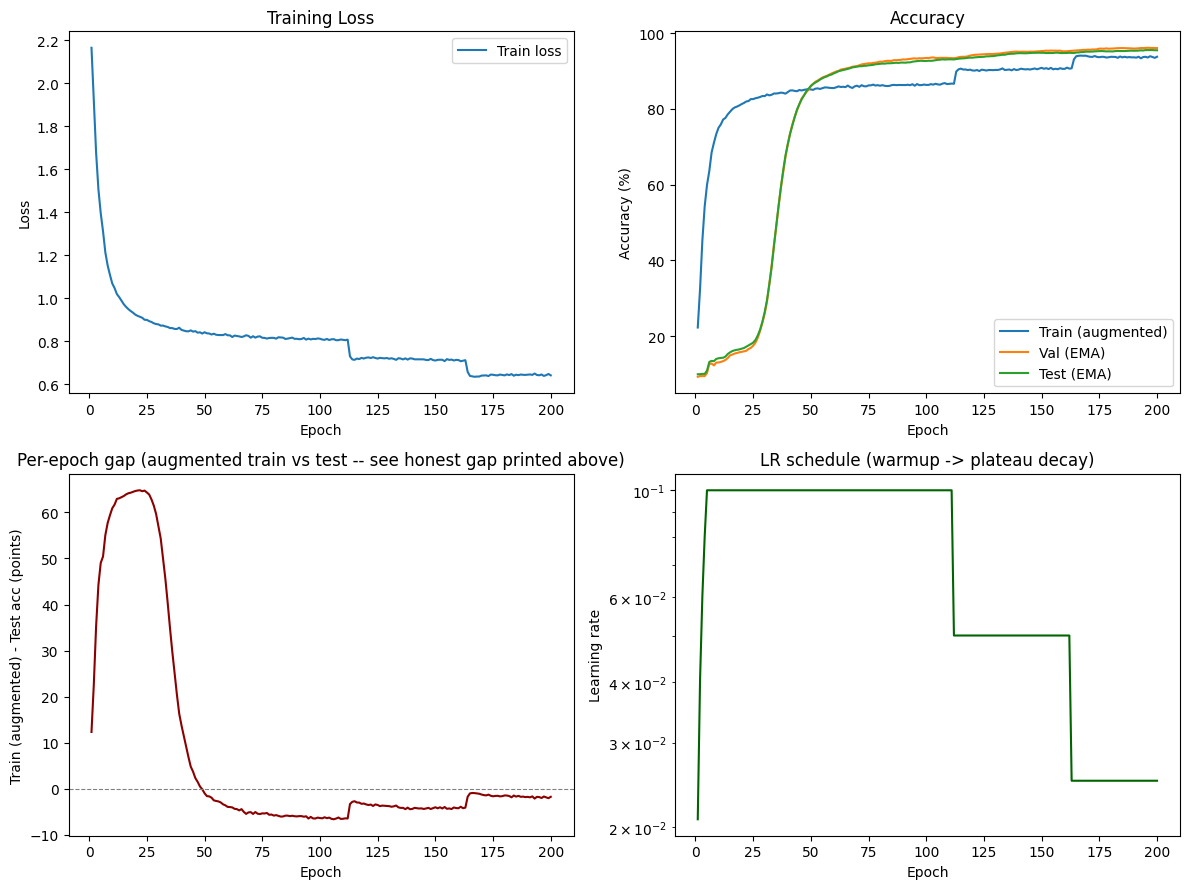

Saved training curves to /content/drive/MyDrive/atdl/resnet18_baseline_training_curves.png


In [ ]:
actual_epochs = len(history["train_loss"])
epochs_range = range(1, actual_epochs + 1)
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

axes[0, 0].plot(epochs_range, history["train_loss"], label="Train loss")
axes[0, 0].set_xlabel("Epoch"); axes[0, 0].set_ylabel("Loss")
axes[0, 0].set_title("Training Loss"); axes[0, 0].legend()

axes[0, 1].plot(epochs_range, history["train_acc"], label="Train (augmented)")
axes[0, 1].plot(epochs_range, history["val_acc_ema"], label="Val (EMA)")
axes[0, 1].plot(epochs_range, history["test_acc_ema"], label="Test (EMA)")
axes[0, 1].set_xlabel("Epoch"); axes[0, 1].set_ylabel("Accuracy (%)")
axes[0, 1].set_title("Accuracy"); axes[0, 1].legend()

gap = [tr - te for tr, te in zip(history["train_acc"], history["test_acc_ema"])]
axes[1, 0].plot(epochs_range, gap, color="darkred")
axes[1, 0].axhline(0, color="gray", linewidth=0.8, linestyle="--")
axes[1, 0].set_xlabel("Epoch"); axes[1, 0].set_ylabel("Train (augmented) - Test acc (points)")
axes[1, 0].set_title("Per-epoch gap (augmented train vs test -- see honest gap printed above)")

axes[1, 1].plot(epochs_range, history["lr"], color="darkgreen")
axes[1, 1].set_xlabel("Epoch"); axes[1, 1].set_ylabel("Learning rate")
axes[1, 1].set_title("LR schedule (warmup -> plateau decay)")
axes[1, 1].set_yscale("log")

plt.tight_layout()
plt.savefig(CURVE_PATH, dpi=150)
plt.show()
print(f"Saved training curves to {CURVE_PATH}")